前半部分：自己写一个超简化版 Tiny CLIP，理解原理。

后半部分：加载真正的 CLIP 模型，拿图片和文字做相似度匹配。

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image,ImageDraw
#PIL 是 Python 很常见的图像处理库。
torch.manual_seed(42)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("运行设备：",device)

C:\Users\Administrator\.conda\envs\rl\lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


运行设备： cpu


In [2]:
'''CLIP 图像和语言的对比学习预训练。
核心就是：让正确匹配的图片和文字越来越接近，让错误匹配的图片和文字越来越远。
它内部有两个编码器：
图片
 ↓
Image Encoder
 ↓
图片向量

文字
 ↓
Text Encoder
 ↓
文字向量'''

'CLIP 图像和语言的对比学习预训练。\n核心就是：让正确匹配的图片和文字越来越接近，让错误匹配的图片和文字越来越远。\n它内部有两个编码器：\n图片\n ↓\nImage Encoder\n ↓\n图片向量\n\n文字\n ↓\nText Encoder\n ↓\n文字向量'

## 1. 页面 CLIP 伪代码

In [3]:
#自己模拟一个超级简化的 CLIP 图像编码器。两个非常简化的“编码器”：一个负责把图片变成 16 维向量，一个负责把文字变成 16 维向量，为后面计算“图片和文字有多相似”做准备。
class TinyImageEncoder(nn.Module):
    def __init__(self, output_dim=16):
        super().__init__()
        self.net = nn.Sequential(#Sequential 的意思就是：按顺序执行里面的网络层。
            nn.Flatten(),
            nn.Linear(3 * 8 * 8, 64),
            nn.ReLU(),#激活，(ReLU(x)=max(0,x))
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size=50, output_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, output_dim)

    def forward(self, x):
        return F.normalize(self.embedding(x).mean(dim=1), dim=-1)


image_encoder = TinyImageEncoder().to(device)
text_encoder = TinyTextEncoder().to(device)
print(image_encoder)
print(text_encoder)

TinyImageEncoder(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=192, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=16, bias=True)
  )
)
TinyTextEncoder(
  (embedding): Embedding(50, 16)
)


In [4]:
batch_size = 4
image_batch = torch.randn(batch_size, 3, 8, 8, device=device)
text_batch = torch.randint(0, 50, (batch_size, 6), device=device)

image_features = image_encoder(image_batch)
text_features = text_encoder(text_batch)

temperature = torch.tensor(10.0, device=device)
logits = image_features @ text_features.T * temperature
labels = torch.arange(batch_size, device=device)

loss_img = F.cross_entropy(logits, labels)
loss_txt = F.cross_entropy(logits.T, labels)
total_loss = (loss_img + loss_txt) / 2

print("图像特征形状：", image_features.shape)
print("文本特征形状：", text_features.shape)
print("相似度矩阵：\n", logits)
print("对比损失：", total_loss.item())

图像特征形状： torch.Size([4, 16])
文本特征形状： torch.Size([4, 16])
相似度矩阵：
 tensor([[ 1.6832, -0.8092, -0.9080, -3.9341],
        [ 2.0609,  1.8773, -0.4645, -0.7658],
        [ 3.4513,  3.0898,  0.7605,  0.8266],
        [-1.9144, -0.5696, -1.9808,  3.8332]], grad_fn=<MulBackward0>)
对比损失： 1.056636095046997


## 2. 完成一次对比学习更新

In [5]:
optimizer = torch.optim.Adam(
    list(image_encoder.parameters()) + list(text_encoder.parameters()),
    lr=0.01
)

optimizer.zero_grad()
total_loss.backward()
optimizer.step()

new_image_features = image_encoder(image_batch)
new_text_features = text_encoder(text_batch)
new_logits = new_image_features @ new_text_features.T * temperature
new_loss = (F.cross_entropy(new_logits, labels) + F.cross_entropy(new_logits.T, labels)) / 2

#这一段真正让模型根据错误修改自己。
print("更新前损失：", total_loss.item())
print("更新后损失：", new_loss.item())

更新前损失： 1.056636095046997
更新后损失： 0.15238435566425323


## 3. 可视化图文相似度矩阵

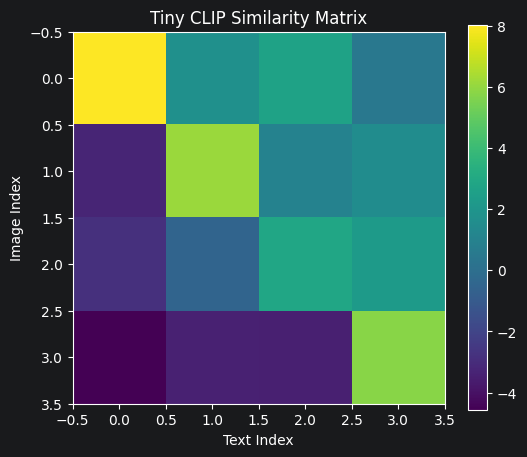

In [6]:
plt.figure(figsize=(6, 5))
plt.imshow(new_logits.detach().cpu().numpy())
plt.xlabel("Text Index")
plt.ylabel("Image Index")
plt.title("Tiny CLIP Similarity Matrix")
plt.colorbar()
plt.show()

## 4. 检查并加载本地真实 CLIP

In [7]:
from transformers import CLIPProcessor, CLIPModel

clip_path = r"D:\11\NLP\data\clip-vit-base-patch32-local"
clip_ready = (
    os.path.isdir(clip_path)
    and os.path.isfile(os.path.join(clip_path, "config.json"))
    and any(
        os.path.isfile(os.path.join(clip_path, name))
        for name in ["model.safetensors", "pytorch_model.bin"]
    )
)

print("CLIP目录：", clip_path)
print("模型准备完成：", clip_ready)

if os.path.isdir(clip_path):
    print("目录文件：", os.listdir(clip_path))

C:\Users\Administrator\.conda\envs\rl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLIP目录： D:\11\NLP\data\clip-vit-base-patch32-local
模型准备完成： True
目录文件： ['config.json', 'merges.txt', 'preprocessor_config.json', 'pytorch_model.bin', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']


In [8]:
if clip_ready:
    processor=CLIPProcessor.from_pretrained(clip_path,local_files_only=True)
    clip_model=CLIPModel.from_pretrained(clip_path,local_files_only=True).to(device); clip_model.eval()
    print("CLIP参数量：",sum(p.numel() for p in clip_model.parameters()))
else: print("请先下载本地CLIP模型。")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP参数量： 151277313


## 5. 创建一张本地测试图片，不读取网络

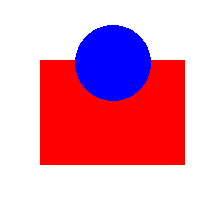

In [9]:
test_image = Image.new("RGB", (224, 224), "white")
draw = ImageDraw.Draw(test_image)
draw.rectangle((40, 60, 184, 164), fill="red")
draw.ellipse((75, 25, 150, 100), fill="blue")

display(test_image)

## 6. 图像与多段英文文本的相似度

构造一张测试图，再让已经预训练好的真实 CLIP 比较这张图片与多个候选文本描述之间的图文相似度。

In [ ]:
clip_texts = ["a red rectangle", "a blue circle", "a photo of a dog", "a green tree"]

if clip_ready:
    clip_inputs = processor(
        text=clip_texts,
        images=test_image,
        return_tensors="pt",
        padding=True
    )
    clip_inputs = {key: value.to(device) for key, value in clip_inputs.items()}

    with torch.no_grad():
        clip_outputs = clip_model(**clip_inputs)

    probabilities = clip_outputs.logits_per_image.softmax(dim=-1)[0].cpu()

    for text, probability in zip(clip_texts, probabilities):
        print(text, round(probability.item(), 4))
else:
    print("模型未准备。")

## 7. 分别获取归一化图像特征和文本特征

In [11]:
if clip_ready:
    with torch.no_grad():
        image_features = clip_model.get_image_features(
            pixel_values=clip_inputs["pixel_values"]
        )
        text_features = clip_model.get_text_features(
            input_ids=clip_inputs["input_ids"],
            attention_mask=clip_inputs["attention_mask"]
        )

    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    cosine_scores = image_features @ text_features.T

    print("图像特征形状：", image_features.shape)
    print("文本特征形状：", text_features.shape)
    print("余弦相似度：", cosine_scores.cpu())
else:
    print("模型未准备。")

图像特征形状： torch.Size([1, 512])
文本特征形状： torch.Size([4, 512])
余弦相似度： tensor([[0.3240, 0.3049, 0.2311, 0.2126]])
